In [1]:
%load_ext autoreload
%autoreload 2

from radiography_toolkit import dicom, plot_calibration, plot_all, plot_diff, plot_quo
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
rad = dicom.load('DICOM/0001002A')
hoja = rad.invert(fondo=4095).crop(0, 0, 330, 3048)
mean, std, info = hoja.measure_weighted(label="Hoja", sheets = 500)
fondo = info['Mean_Intensity'] + info['Std_Dev']
info


{'Filename': '0001002A',
 'Label': 'Hoja',
 'Thickness_mm': 0.0,
 'Sheet_Count': 500,
 'Mean_Intensity': np.float64(4006.5255388530977),
 'Std_Dev': np.float64(34.4526600130814),
 'Max_Bit': 4095}

In [3]:
dataset = { # 'nombre_del_archivo': cantidad_de_hojas
    '0001002A': 500,
    '0001003A': 450,
    '0001005A': 407,
    '0001006A': 365,
    '0001007A': 341,
    '0001008A': 297,
    '0001009A': 254,
    '0001010A': 221,
    '0001011A': 186,
    '0001012A': 141,
    '0001013A': 107,
    '0001014A': 97,
    '0001015A': 87,
    '0001016A': 77,
    '0001017A': 72,
    '0001018A': 62,
    '0001019A': 42,
    '0001020A': 52,
    '0001021A': 32,
    '0001022A': 12,
    '0001023A': 2,
    '0001024A': 1,
    '0001025A': 5,
}
unit_thickness = 0.1058 # mm por hoja
paper_density = 75E-4 #g/cm^2
aluminum_density = 2.7 #g/cm^3

mu_H = 3.458E-01 #cm^2/g
mu_C = 2.076E-01
mu_O = 2.585E-01
mu_Ca = 1.830E00

mu_rho = 0.50*mu_O+0.40*mu_C+0.5*mu_H+0.05*mu_Ca
mu = mu_rho*paper_density
print(f'MU in Paper Sheets: {mu}')

mu_Al = 5.685E-01
mu_al = mu_Al*aluminum_density*1E-01 # mm^-1
print(f'MU in Aluminum Plate: {mu_al}')

MU in Paper Sheets: 0.0035751750000000003
MU in Aluminum Plate: 0.15349500000000002


In [4]:
historial_og = []
historial_sf = []
for file, count in dataset.items():
    path = os.path.join('DICOM', file)
    if os.path.exists(path):
        try:
            rad_og = dicom.load(path)
            rad_sf = dicom.load(path)
            paper_og = rad_og.invert(fondo=4095).crop(550, 600, 1300, 1750)
            paper_sf = rad_sf.invert(fondo=fondo).crop(550, 600, 1300, 1750)
            paper_thickness = count * unit_thickness
            
            _, _, info_og = paper_og.measure_weighted(
                label="Serie_Calibracion", 
                thickness=paper_thickness, 
                sheets=count
            )
            historial_og.append(info_og)
            
            _, _, info_sf = paper_sf.measure_weighted(
                label="Serie_Calibracion", 
                thickness=paper_thickness, 
                sheets=count
            )
            historial_sf.append(info_sf)
            print(f"{path} procesado con éxito.")
            
        except Exception as e:
            print(f"Error procesando {path}; {e}")
    else:
        print(f"Archivo {path} no encontrado.")

DICOM\0001002A procesado con éxito.
DICOM\0001003A procesado con éxito.
DICOM\0001005A procesado con éxito.
DICOM\0001006A procesado con éxito.
DICOM\0001007A procesado con éxito.
DICOM\0001008A procesado con éxito.
DICOM\0001009A procesado con éxito.
DICOM\0001010A procesado con éxito.
DICOM\0001011A procesado con éxito.
DICOM\0001012A procesado con éxito.
DICOM\0001013A procesado con éxito.
DICOM\0001014A procesado con éxito.
DICOM\0001015A procesado con éxito.
DICOM\0001016A procesado con éxito.
DICOM\0001017A procesado con éxito.
DICOM\0001018A procesado con éxito.
DICOM\0001019A procesado con éxito.
DICOM\0001020A procesado con éxito.
DICOM\0001021A procesado con éxito.
DICOM\0001022A procesado con éxito.
DICOM\0001023A procesado con éxito.
DICOM\0001024A procesado con éxito.
DICOM\0001025A procesado con éxito.


In [5]:
dicom.save_to_csv(historial_og,filename="calibration_thickness_og.csv", overwrite = True)
dicom.save_to_csv(historial_sf,filename="calibration_thickness_sf.csv", overwrite = True)

Archivo 'calibration_thickness_og.csv' sobrescrito con 23 registros.
Archivo 'calibration_thickness_sf.csv' sobrescrito con 23 registros.


In [6]:
with open("historial_og.json", "w", encoding="utf-8") as f:
    json.dump(historial_og, f, ensure_ascii=False, indent=4)
    
with open("historial_sf.json", "w", encoding="utf-8") as f:
    json.dump(historial_sf, f, ensure_ascii=False, indent=4)

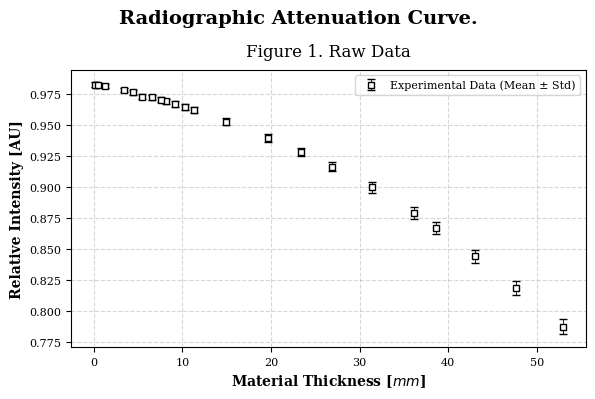

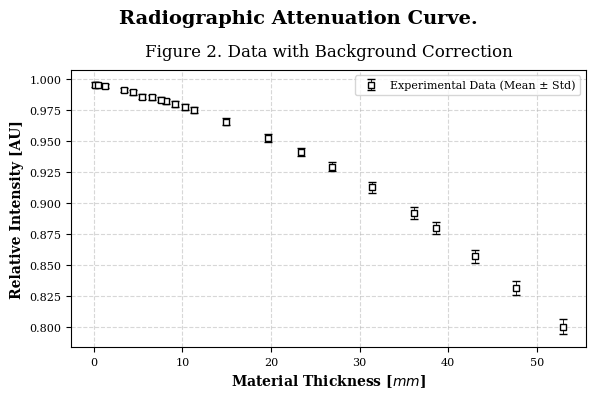

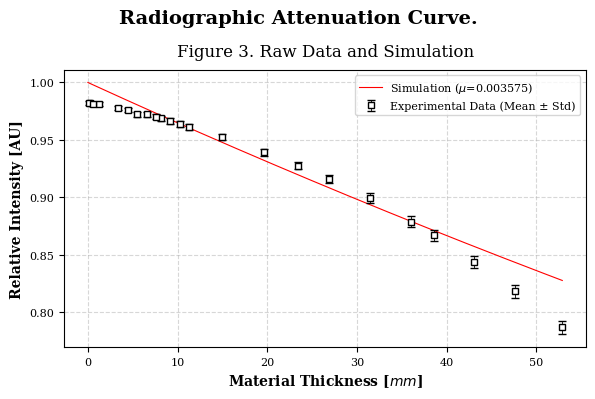

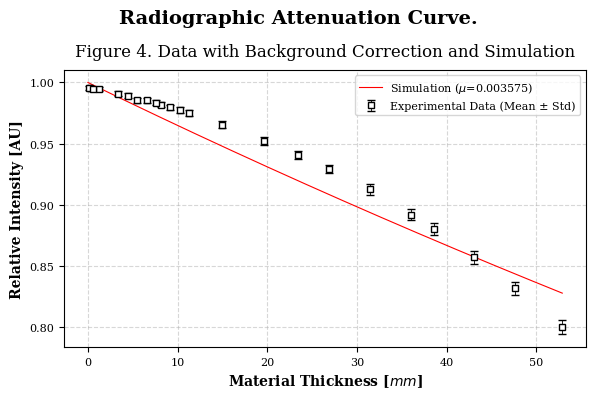

In [7]:
plot_calibration('calibration_thickness_og.csv', unit_thickness, mu=None, label = 'raw_data', figure = 1, caption = 'Raw Data')
plot_calibration('calibration_thickness_sf.csv', unit_thickness, mu=None, label = 'no_bkg_data', figure = 2, caption = 'Data with Background Correction')
plot_calibration('calibration_thickness_og.csv', unit_thickness, mu=mu, label = 'raw_fit', figure = 3, caption = 'Raw Data and Simulation')
plot_calibration('calibration_thickness_sf.csv', unit_thickness, mu=mu, label = 'no_bkg_fit', figure = 4, caption = 'Data with Background Correction and Simulation')

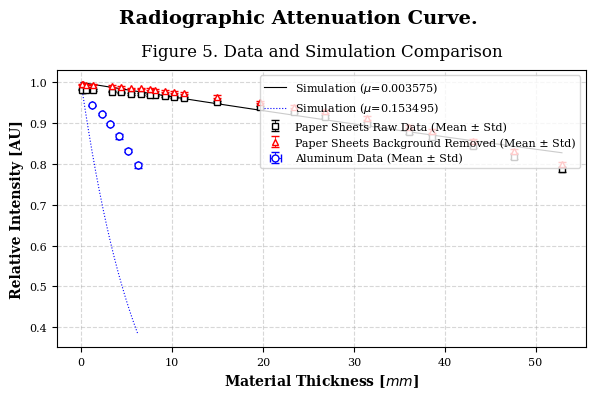

In [8]:
plot_all('calibration_thickness_og.csv', 'calibration_thickness_sf.csv', 'aluminum_thickness.csv', unit_thickness, mu=mu, mu_al = mu_al, 
         xlim = None, label = 'comparison', figure = 5, caption = 'Data and Simulation Comparison')

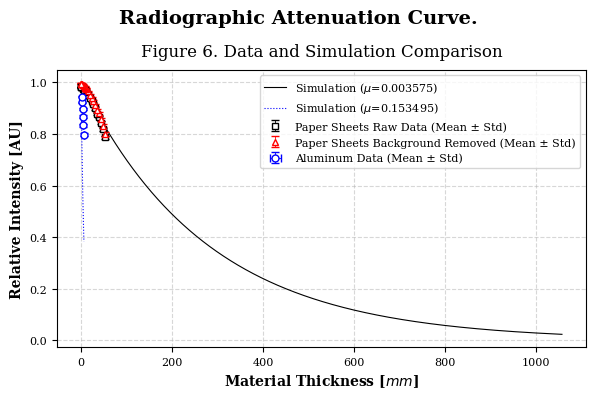

In [12]:
plot_all('calibration_thickness_og.csv', 'calibration_thickness_sf.csv', 'aluminum_thickness.csv', unit_thickness, mu=mu, mu_al = mu_al, 
         xlim = 10000, label = 'comparison', figure = 6, caption = 'Data and Simulation Comparison')

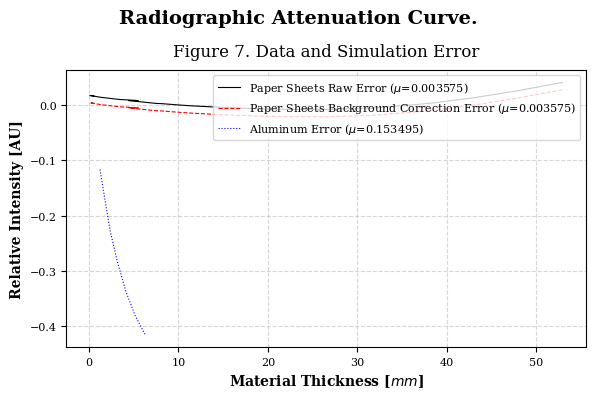

In [13]:
plot_diff('calibration_thickness_og.csv', 'calibration_thickness_sf.csv', 'aluminum_thickness.csv', unit_thickness, mu=mu, mu_al = mu_al, 
         xlim = 10000, label = 'error', figure = 7, caption = 'Data and Simulation Error')

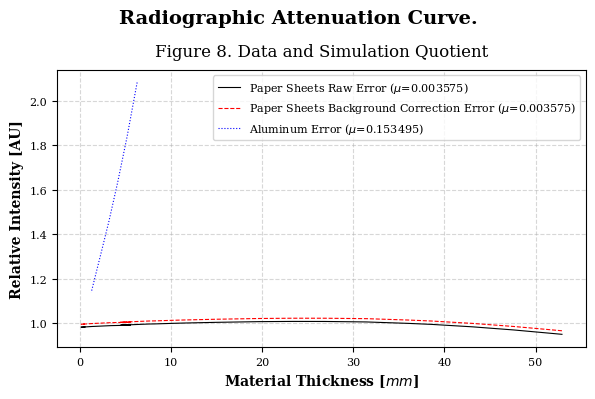

In [14]:
plot_quo('calibration_thickness_og.csv', 'calibration_thickness_sf.csv', 'aluminum_thickness.csv', unit_thickness, mu=mu, mu_al = mu_al, 
         xlim = 10000, label = 'quotient', figure = 8, caption = 'Data and Simulation Quotient')